## Setup: Only for Google Colab

**If you are running this notebook locally, skip this section** — the helper files and data already sit next to the notebook.

On Google Colab, run the cells below first. They fetch the helper modules and data for this tutorial from the [BAMB2026 GitHub repository](https://github.com/bambschool/BAMB2026) and install the required packages. Check the left sidebar afterwards to confirm the files appeared, and make sure there are no download or installation errors.

In [ ]:
# Base path to the Module 4 files in the BAMB2026 GitHub repository
RAW = 'https://raw.githubusercontent.com/bambschool/BAMB2026/Module-4/Module%204/'

# Helper modules
py_files = ['environments.py', 'models.py']
for f in py_files:
    !wget -q -O {f} "{RAW}{f}"

print('Downloads complete.')

In [ ]:
# Install required packages
!pip install -q numpy matplotlib scipy gymnasium

That is everything Colab needs. The rest of the notebook runs identically on Colab and locally. **Now continue below.**

---

# Tutorial: Chinese Restaurant Processes and Non-Stationary Environments

**Prepared by:** Charley M. Wu (TU Darmstadt; [hmc-lab.com](https://hmc-lab.com/)) for the 2026 Barcelona Summer School for Advanced Modeling of Behavior (BAMB; https://www.bambschool.org/)

**Module 4 // Day 1 // Block 2**

Welcome to this tutorial on the **Chinese Restaurant Process (CRP)** and how it can be combined with model-based reinforcement learning. In the previous notebook, you saw how DYNA-Q speeds up learning by building an internal model of the environment and replaying transitions for planning. Here, we tackle a harder and more realistic question: *what should an agent do when the environment itself keeps changing?*

This notebook introduces two key ideas and then connects them:

1. **Chinese Restaurant Process (CRP)** is a Bayesian nonparametric method for unsupervised clustering that lets the number of clusters grow with the data, without requiring you to specify it in advance
2. **DYNA-Q** is the model-based RL algorithm from the previous notebook, now extended to maintain *multiple* models of the environment (one per inferred environment cluster)

**The core challenge:** Imagine you're an animal foraging in various food patches. You've spent days learning the layout of the current patch, where the food is, and what paths are blocked. Then one morning, the patch is depleted and you move on to a new patch. This new patch seem somewhat familiar, but is it truly a patch you visited last season, or is it a completely new one? If you correctly identify it, you can retrieve your old knowledge to inform your search for food. If you guess wrong, you'll keep trying moves that lead nowhere. Your challenge is to solve this without knowing how many patches exist.

This is related to questions in cognitive neuroscience about how the brain forms and retrieves memories of distinct *task contexts* (Gershman & Niv, 2010; Collins & Frank, 2013). The CRP offers a mathematically principled way to determine what is a new vs. a previously learned context, where the number of contexts can be treated as an unknown that grows as new evidence accumulates.

In [1]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

from environments import (
    create_custom_environment,
    generate_sticky_env_sequence,
)
from models import (
    run_baseline_sequence,
    run_persistent_dyna_q_sequence,
    run_diner_sequence,
)

def set_seed(seed=0):
    np.random.seed(seed)
    random.seed(seed)

def smooth(x, w=5):
    return np.convolve(x, np.ones(w) / w, mode='valid')

set_seed(2026)

---
## 1. The Chinese Restaurant Process


The name **Chinese Restaurant Process (CRP)** comes from a mathematical metaphor introduced in the early 1980s by statisticians Jim Pitman and Lester Dubins. The urban legend is that the name was inspired by the seemingly infinite seating capacity of Chinese restaurants in San Francisco's Chinatown. 

Imagine a restaurant with **infinitely many tables**. Customers arrive one by one and choose where to sit according to a simple rule:

- **Join an existing table** with probability proportional to how many people are already sitting there
- **Start a new table** with probability proportional to a concentration parameter $\alpha > 0$

When the $n+1$-th customer arrives, their choice is:

$$
p(\text{sit at table } k) = \frac{n_k}{n + \alpha}, \qquad k = 1, \ldots, K
$$
$$
p(\text{open a new table}) = \frac{\alpha}{n + \alpha}
$$

where:
- $n_k$ is the **number of customers at a specific table $k$**
- $n$ is the **total number of customers already seated**; $n = \sum_k n_k$ 
- $K$ is the number of occupied tables so far
- $\alpha$ is the concentration parameter (see below)

Note that these probabilities sum to one: $\sum_{k=1}^K \frac{n_k}{n + \alpha} + \frac{\alpha}{n + \alpha} = \frac{n + \alpha}{n + \alpha} = 1$, because $\sum_k n_k = n$.

This rule has a **rich-get-richer** property: large tables attract more customers, making them larger still, which attracts yet more customers. Yet there is always some chance of a new table opening. The parameter $\alpha$ controls this tradeoff:
- **Small $\alpha$** → customers cluster tightly at a few tables
- **Large $\alpha$** → customers spread across many tables

A nice mathematical property of the CRP is that the expected number of tables is $\alpha \ln n$, meaning the cluster count grows logarithmically with the number of customers. This points to a general property of **nonparametric**, whereby the complexity of the model grows with the complexity of the data.

Let's first build some intuition about the CRP, then later see how it can be combined with model-based RL.

In [2]:
def simulate_crp(n_customers, alpha, seed=0):
    """Simulate a Chinese Restaurant Process.

    Returns a list of table assignments (0-indexed) for each customer,
    and a list of customer counts per table.
    """
    rng = np.random.RandomState(seed)
    assignments = []
    table_counts = []  # table_counts[k] = number of customers at table k

    for _ in range(n_customers):
        n = len(assignments)  # customers seated so far

        # Probability vector: existing tables + one new-table option
        counts = np.array(table_counts + [alpha])  # alpha is the "count" for the new-table option
        probs  = counts / (n + alpha)              # normalise everything at once

        chosen = rng.choice(len(probs), p=probs)

        if chosen == len(table_counts):  # open a new table
            table_counts.append(1)
        else:                            # join an existing table
            table_counts[chosen] += 1

        assignments.append(chosen)

    return assignments, table_counts


# Sanity check
assignments, counts = simulate_crp(n_customers=20, alpha=1.0)
print('Table assignments:', assignments)
print('Customers per table:', counts)
print(f'Total tables opened: {len(counts)}')

Table assignments: [0, 1, 1, 1, 1, 1, 1, 2, 3, 1, 2, 1, 1, 3, 1, 1, 0, 2, 2, 3]
Customers per table: [2, 11, 4, 3]
Total tables opened: 4


### Visualising the effect of $\alpha$

Let's see how different values of $\alpha$ change the seating pattern. Run the cell below with different values and observe how the number of occupied tables changes.

Each dot represents a customer (ordered by arrival time from top to bottom). Each colour represents a distinct table. Notice how small $\alpha$ produces a few heavily-occupied tables, while large $\alpha$ spreads customers across many smaller ones.

**Exercise 1.** Try $\alpha = 0.01$ and $\alpha = 100$. What happens in each extreme? What does this tell you about the kinds of tasks a CRP prior would be appropriate for?

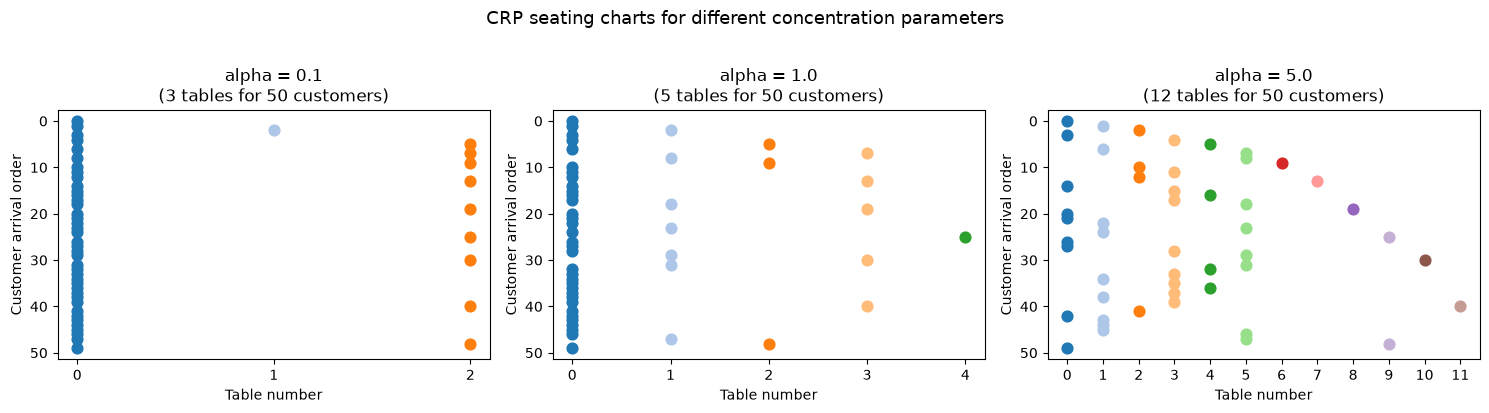

alpha=0.1: 3 tables, sizes = [40, 9, 1]
alpha=1.0: 5 tables, sizes = [34, 7, 5, 3, 1]
alpha=5.0: 12 tables, sizes = [9, 9, 9, 8, 4, 4, 2, 1, 1, 1, 1, 1]


In [3]:
# --- Try changing alpha and re-running this cell ---
alpha_values = [0.1, 1.0, 5.0]   # <-- change these!
n_customers = 50 # <-- you can also change this as well!

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, alpha in zip(axes, alpha_values):
    assignments, counts = simulate_crp(n_customers, alpha, seed=2026)
    n_tables = len(counts)
    cmap = plt.colormaps.get_cmap('tab20')

    for i, (table, color_idx) in enumerate(zip(assignments, assignments)):
        ax.scatter(table, i, color=cmap(color_idx), s=60, zorder=3)

    ax.set_title(
        f'alpha = {alpha}\n({n_tables} tables for {n_customers} customers)',
        fontsize=12,
    )
    ax.set_xlabel('Table number')
    ax.set_ylabel('Customer arrival order')
    ax.invert_yaxis()
    ax.set_xticks(range(n_tables))

plt.suptitle('CRP seating charts for different concentration parameters', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

for alpha in alpha_values:
    _, counts = simulate_crp(n_customers, alpha, seed=2026)
    print(f'alpha={alpha:.1f}: {len(counts)} tables, sizes = {sorted(counts, reverse=True)}')

### From restaurant tables to environment models

Now let's turn back to an RL setting. Let's replace *customer* with *episode* and *table* with *environment cluster*:

| Restaurant | RL setting |
|---|---|
| Customer | Episode |
| Table | Latent environment cluster |
| Dish served at a table | Q-table + transition model for that environment |
| $\alpha$ | Tendency to create a new environment model |

At the start of each new episode, the agent asks:
> *"Does this environment look like one I've been in before? Or am I somewhere new?"*

If it correctly recognises a familiar environment, it can **reuse the Q-values and model representation it already learned**. The CRP provides the prior over how likely that is.

**A note on when $\alpha$ matters.** In the current setting, the environments are **deterministic and perfectly distinguishable**. Thus, a single contradictory transition is conclusive, such that the probe can fully resolve the cluster identity before $\alpha$ has any practical influence on assignment. In this regime $\alpha$ mainly controls how readily a new cluster is opened at the very start of a sequence, before the probe can rule out any existing clusters. Once the probe is collected, the evidence (i.e., likelihood) dominates the posterior, and the CRP prior on existing clusters matters relatively little.

However, the CRP prior and the value of $\alpha$ matters much more in realistic setting:

| Setting | Why $\alpha$ matters more |
|---|---|
| **Stochastic transitions** | No single step can be definitively contradictory, so the decision to open a new cluster must weigh the CRP prior against noisy, accumulating evidence. A larger $\alpha$ makes the agent more willing to create a new model, whereas a smaller $\alpha$ is more likely to reuse a previous model. |
| **Partially-distinguishable environments** | If two environments share many transitions (e.g., Exercise 5), the probe may return ambiguous evidence, and the CRP prior acts as a tie-breaker. Lowering $\alpha$ biases the agent toward re-using existing clusters even when the evidence is inconclusive. |

The exercises in Section 5 let you explore these regimes by varying `crp_alpha`.

## 2. Three Diverse Environments

We'll work with the same three 10×10 gridworld environments from the previous DYNA-Q notebook. These environments are designed to require **divergent policies**. Each environment places its goal in a structurally different location, making knowledge from one environment not just useless, but actively misleading in the others.

In [4]:
env_configs = {
    "top_right": '''
    A . . . . . . . . G
    # . # # . . . . . .
    . . . # . . . . . .
    . . . # . . . . . .
    . . . # . . . . . .
    . . . # . . . . . .
    . . . # . . . . . .
    . . . # # # # # . #
    . . . . . . . . . .
    . . . . . . . . . .''',
    "bottom_left": '''
    A # . . . . . . . .
    . . . . . . . . . .
    . # . . . . . . . .
    . # # # # # # . . .
    . . . . . . # . . .
    . . . . . . # . . .
    . . . . . . # . . .
    . . . . . . # # . #
    . . . . . . . . . .
    G . . . . . . . . .''',
    "s_maze": '''
    A . . . . . . . . .
    . . . . . . . . . .
    . . . . . . . . . .
    # # # # # # # # . .
    . . . . . . . . . .
    . . . . . . . . . .
    . . # # # # # # # #
    . . . . . . . . . .
    . . . . . . . . . .
    . . . . . . . . . G''',
}

envs = {
    name: create_custom_environment(ascii_map=ascii_map, max_steps=200).build()
    for name, ascii_map in env_configs.items()
}

for name, env in envs.items():
    env.render_mode = 'ansi'
    print(f'--- {name} ---')
    print(env.render())

--- top_right ---

A . . . . . . . . G
# . # # . . . . . .
. . . # . . . . . .
. . . # . . . . . .
. . . # . . . . . .
. . . # . . . . . .
. . . # . . . . . .
. . . # # # # # . #
. . . . . . . . . .
. . . . . . . . . .
--- bottom_left ---

A # . . . . . . . .
. . . . . . . . . .
. # . . . . . . . .
. # # # # # # . . .
. . . . . . # . . .
. . . . . . # . . .
. . . . . . # . . .
. . . . . . # # . #
. . . . . . . . . .
G . . . . . . . . .
--- s_maze ---

A . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . .
# # # # # # # # . .
. . . . . . . . . .
. . . . . . . . . .
. . # # # # # # # #
. . . . . . . . . .
. . . . . . . . . .
. . . . . . . . . G



### A Non-Stationary Task: Sticky Environment Sequences

Real environments are rarely static. Imagine you're an animal that visits the same three foraging patches repeatedly, but the patches rotate seasonally. You spend several weeks in one patch, then it becomes barren and you move to the next. Your best strategy is to recognize, *as quickly as possible*, which patch you're currently in, and whether you can reuse past experiences to forage more effectively.

We model this dynamic environment scenario using a **sticky process**: at each episode, the agent stays in the current environment with probability `stay_prob`, or switches to a randomly chosen environment otherwise. This creates **long runs** in the same environment, giving the agent time to learn it thoroughly, punctuated by **rare switches** that would catch a naïve agent off guard.

Crucially, the agent does not know *when* a switch has happened. It must infer this from experience. Run the cell below to visualise the episode sequence before we compare agents.


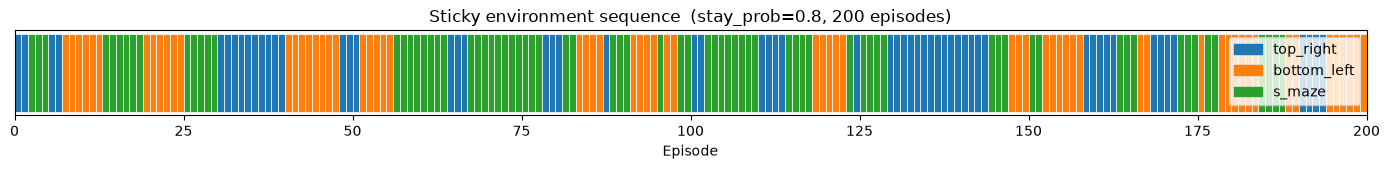

Episode counts per environment:
  top_right: 59 episodes
  bottom_left: 66 episodes
  s_maze: 75 episodes
Number of environment switches: 47


In [5]:
# --- Try changing these parameters ---
n_episodes = 200      # total episodes in the sequence
stay_prob  = 0.80     # probability of staying in the same environment
# ------------------------------------

env_names = ['top_right', 'bottom_left', 's_maze']
dynamic_sequence = generate_sticky_env_sequence(env_names, n_episodes, stay_prob=stay_prob, seed=2026)

# Visualise the sequence as a colour-coded timeline
env_color = {'top_right': 'tab:blue', 'bottom_left': 'tab:orange', 's_maze': 'tab:green'}
fig, ax = plt.subplots(figsize=(14, 1.8))
for ep, name in enumerate(dynamic_sequence):
    ax.barh(0, 1, left=ep, color=env_color[name], edgecolor='white', linewidth=0.5)

patches = [mpatches.Patch(color=env_color[n], label=n) for n in env_names]
ax.legend(handles=patches, loc='upper right', fontsize=10)
ax.set_xlabel('Episode')
ax.set_yticks([])
ax.set_title(f'Sticky environment sequence  (stay_prob={stay_prob}, {n_episodes} episodes)', fontsize=12)
ax.set_xlim(0, n_episodes)
plt.tight_layout()
plt.show()

from collections import Counter
counts = Counter(dynamic_sequence)
print('Episode counts per environment:')
for name in env_names:
    print(f'  {name}: {counts[name]} episodes')
n_switches = sum(1 for i in range(1, len(dynamic_sequence)) if dynamic_sequence[i] != dynamic_sequence[i-1])
print(f'Number of environment switches: {n_switches}')

---
## 3. Why Simpler Approaches Fail

Before introducing a new CRP informed model, let's understand precisely *why* simpler approaches fail. Here are two natural strategies, which fail for completely opposite reasons.

| Strategy | What it does | Why it fails |
|---|---|---|
| **Fresh-start DYNA-Q** | Resets Q-table and model at the start of every episode | Never transfers knowledge and must relearn every environment from scratch|
| **Persistent DYNA-Q** | Keeps one shared Q-table and model across all episodes | Accumulates experience, but mixes contradictory information from environments with potentially divergent optimal policies |


In [6]:
# Shared hyperparameters for all three agents
eta            = 0.1   # Q-learning learning rate (η)
gamma          = 0.99  # TD discount 
epsilon        = 0.15  # epsilon-greedy exploration
planning_steps = 10    # DYNA-Q planning steps per real step
crp_alpha = 1.0    # CRP concentration parameter  (try 0.1, 1.0, 5.0)


set_seed(2026)

# --- Fresh-start: reset Q-table and model at the start of every episode ---
fresh_returns = run_baseline_sequence(
    dynamic_sequence, envs, eta, gamma, epsilon, planning_steps
)

# --- Persistent: one shared Q-table across all episodes ---
persistent_returns = run_persistent_dyna_q_sequence(
    dynamic_sequence, envs, eta, gamma, epsilon, planning_steps
)

print(f'Simulated {n_episodes} episodes for both baseline agents.')

Simulated 200 episodes for both baseline agents.


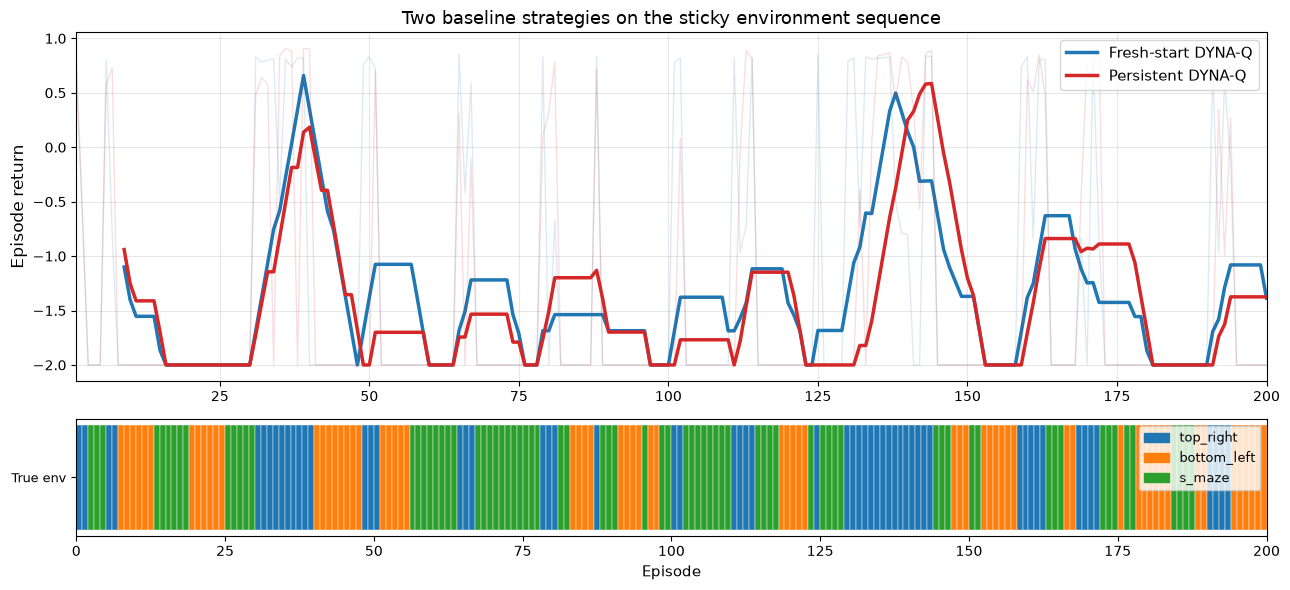

Mean return (all 200 episodes):
  Fresh-start : -1.364  (never improves; relearns every time)
  Persistent  : -1.430  (mixes contradictory Q-values, near random)


In [7]:
# Plot the two baseline strategies (their failure modes are quite different)
eps = np.arange(1, n_episodes + 1)
w = 9

fig, axes = plt.subplots(2, 1, figsize=(13, 6), gridspec_kw={'height_ratios': [3, 1]})
ax = axes[0]
for returns, color, label in [
    (fresh_returns,      'tab:blue', 'Fresh-start DYNA-Q'),
    (persistent_returns, 'tab:red',  'Persistent DYNA-Q'),
]:
    ax.plot(eps, returns, color=color, alpha=0.15, linewidth=1)
    ax.plot(eps[w - 1:], smooth(returns, w), color=color, linewidth=2.5, label=label)

ax.set_ylabel('Episode return', fontsize=12)
ax.set_title('Two baseline strategies on the sticky environment sequence', fontsize=13)
ax.legend(fontsize=11, loc = 'upper right')
ax.grid(alpha=0.3)
ax.set_xlim(1, n_episodes)

ax2 = axes[1]
for ep, name in enumerate(dynamic_sequence):
    ax2.barh(0.5, 1, left=ep, color=env_color[name], edgecolor='white', linewidth=0.3)
ax2.set_yticks([0.5])
ax2.set_yticklabels(['True env'], fontsize=9)
ax2.set_xlabel('Episode', fontsize=11)
ax2.set_xlim(0, n_episodes)
patches = [mpatches.Patch(color=env_color[n], label=n) for n in env_names]
ax2.legend(handles=patches, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

print(f'Mean return (all {n_episodes} episodes):')
print(f'  Fresh-start : {np.mean(fresh_returns):.3f}  (never improves; relearns every time)')
print(f'  Persistent  : {np.mean(persistent_returns):.3f}  (mixes contradictory Q-values, near random)')

---
## 4. DINER: Dyna with Inferred Nonparametric Environment Recurrence

Now let's introduce **DINER**, an algorithm that combines the CRP prior with DYNA-Q to solve the dynamic environment problem. This is a new model (*I think*) that I came up with for this tutorial. But it continues a tradition of using Bayesian nonparametric methods for multi-task and lifelong reinforcement learning (Wilson et al., 2007; Sanders, Wilson, & Gershman, 2020; Wang et al., 2022).

### The probe: deliberate context identification

At the start of each episode, before any learning begins, DINER collects a **probe**: a short sequence of deliberately chosen transitions that act as a diagnostic signature of the current environment. The probe always begins by executing all four actions from the start state. Here, these transitions are maximally informative because walls are placed differently near position `A` in each environment, so the same action leads to a different next state. A handful of additional random steps follow to collect further evidence.

A key advantage of probing with *all* actions from the start state, rather than waiting for information to accumulate during the episode, is that disambiguation is often achieved in just 4 steps, before any learning has occurred or any reward has been collected. The probe is entirely separate from the learning episode that follows.

### Algorithm step by step

1. **Probe the environment**: try all 4 actions from the start state, then take a few random steps. Each probe step incurs the same step cost as any other transition (−0.01/step), so with `n_probe = 10` DINER pays approximately −0.1 extra per episode. 

2. **Check each stored cluster** against the probe via contradiction detection:
   - If the probe contains $(s, a) \rightarrow s'_{\text{new}}$ but the cluster's stored probe has $(s, a) \rightarrow s'_{\text{stored}} \neq s'_{\text{new}}$ then that cluster is **ruled out**
   - Because the environments here are *deterministic*, a single contradiction is conclusive.

3. **If every cluster is ruled out**, open a new cluster with a fresh Q-table. Then store this probe as its identity.

4. **Compute the Bayesian posterior over clusters and sample from it.** By Bayes' rule, posterior $\propto$ prior $\times$ likelihood:

$$
p(k \mid \text{probe}) \;\propto\; \underbrace{\frac{n_k}{n + \alpha}}_{\text{CRP prior}} \;\cdot\; \underbrace{\mathbf{1}[\text{cluster } k \text{ consistent}]}_{\text{likelihood}}
$$

   - **Prior**: the CRP prior describes *"how likely is cluster $k$ before seeing the probe?"* Frequently visited clusters carry more prior weight (rich-get-richer), with the concentration parameter $\alpha$ defining the probability of opening a new cluster. However, that only happens im step 3 only when *every* cluster has been ruled out.

   - **Likelihood**: the probe transitions serve as evidence, answering *"is cluster $k$ compatible with what I just observed?"* Here $\mathbf{1}[\cdot]$ is the **indicator function**, which equals $1$ when the bracketed condition holds and $0$ otherwise. A cluster with any probe contradiction receives $\mathbf{1}[\cdot] = 0$, zeroing out its posterior entirely. However, a consistent cluster receives $\mathbf{1}[\cdot] = 1$. 

   The posterior is therefore proportional to the CRP prior, but with all ruled-out clusters zeroed out. Among the clusters that survive the probe, the posterior is proportional to how often each cluster has previously been visited. In settings with *stochastic* state transitions, the hard indicator function $\mathbf{1}[\cdot]$ can be replaced by a softmax indicating the probability of the probe transitions under each cluster's transition model. 

5. **Run the full episode** using the selected cluster's Q-table and transition model, with an **ε-greedy** policy. This is identical to the DYNA-Q agents above, allowing performance from all three models in this notebook to be directly comparable.

6. **Update** the cluster's Q-values and model from the episode's real transitions.

7. **Planning** steps as before, simulating state transitions from the model and updating Q-values

**Probing from the start state works well here**, but might not in other environments. From position (0, 0):
- Going DOWN is **blocked** in `top_right` but open in the other two.
- Going RIGHT is **blocked** in `bottom_left` but open in the other two.
- `s_maze` leaves both open.

Thus, every (RIGHT result, DOWN result) pair is unique across environments, such that two probe steps are sufficient to conclusively identify the environment. This will not always be the case and is something that can be explored as an extension.

In [8]:
# Run DINER and see how many clusters it identifies via probe comparison
diner_returns, diner_assignments, clusters = run_diner_sequence(
    dynamic_sequence, envs,
    crp_alpha=crp_alpha, eta=eta, gamma=gamma,
    epsilon=epsilon, planning_steps=planning_steps,
    n_probe=10, seed=0,
)

print(f'DINER learned {len(clusters)} clusters  (true number of environments: {len(env_names)})')

DINER learned 3 clusters  (true number of environments: 3)


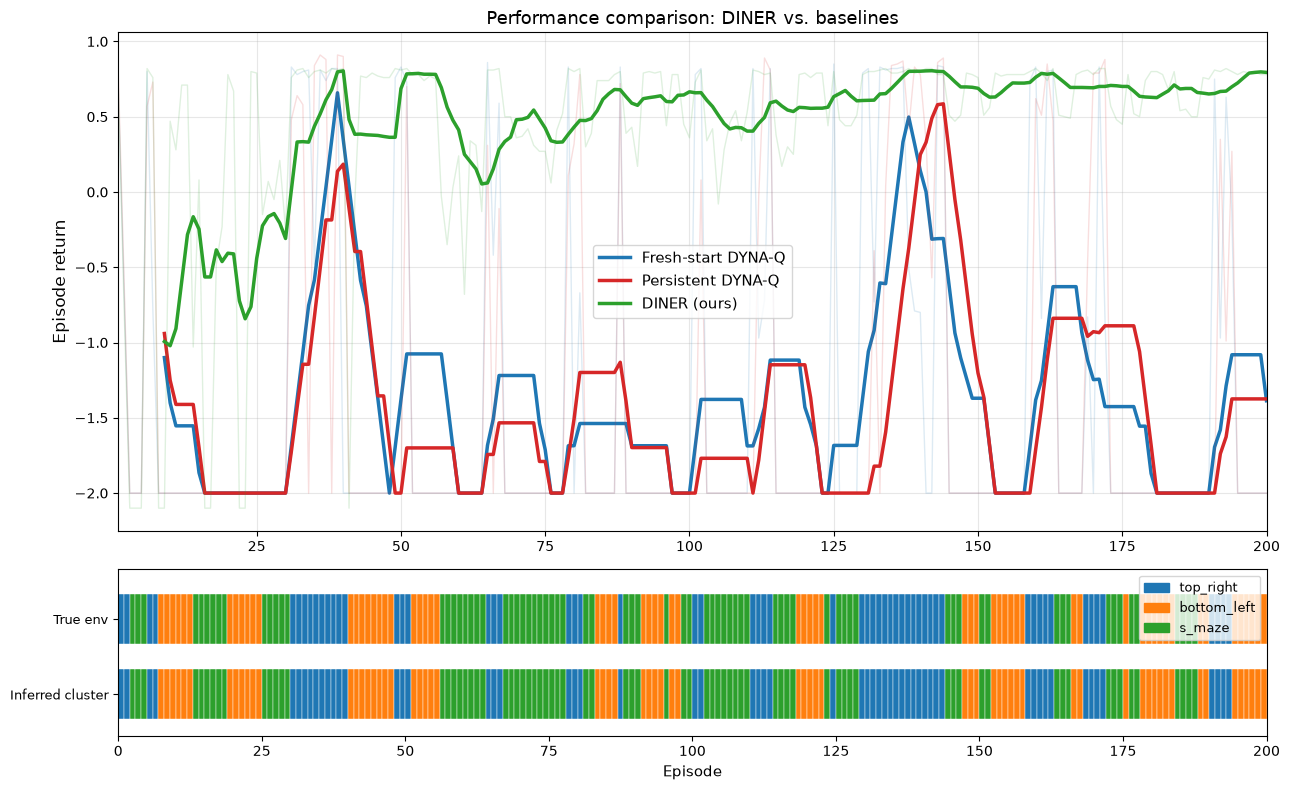

Average returns (all episodes):
  Fresh-start DYNA-Q : -1.364
  Persistent DYNA-Q  : -1.430
  DINER              : 0.449

Average returns (last 50 episodes):
  Fresh-start DYNA-Q : -1.484
  Persistent DYNA-Q  : -1.478
  DINER              : 0.710


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), gridspec_kw={'height_ratios': [3, 1]})

# --- Learning curves ---
ax = axes[0]
w = 9

for returns, color, label in [
    (fresh_returns,      'tab:blue',   'Fresh-start DYNA-Q'),
    (persistent_returns, 'tab:red',    'Persistent DYNA-Q'),
    (diner_returns,      'tab:green',  'DINER (ours)'),
]:
    ax.plot(eps, returns, color=color, alpha=0.15, linewidth=1)
    ax.plot(eps[w - 1:], smooth(returns, w), color=color, linewidth=2.5, label=label)

ax.set_ylabel('Episode return', fontsize=12)
ax.set_title('Performance comparison: DINER vs. baselines', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim(1, n_episodes)

# --- True environment vs inferred cluster ---
ax2 = axes[1]
for ep, name in enumerate(dynamic_sequence):
    ax2.barh(0.65, 1, left=ep, color=env_color[name], edgecolor='white', linewidth=0.3, height=0.3)

from collections import Counter
cluster_env = {}
for name, k in zip(dynamic_sequence, diner_assignments):
    cluster_env.setdefault(k, []).append(name)
cluster_color = {
    k: env_color[Counter(v).most_common(1)[0][0]]
    for k, v in cluster_env.items()
}
for ep, k in enumerate(diner_assignments):
    ax2.barh(0.2, 1, left=ep, color=cluster_color[k], edgecolor='white', linewidth=0.3, height=0.3)

ax2.set_yticks([0.2, 0.65])
ax2.set_yticklabels(['Inferred cluster', 'True env'], fontsize=9)
ax2.set_xlabel('Episode', fontsize=11)
ax2.set_xlim(0, n_episodes)
ax2.set_ylim(-0.05, 0.95)
patches = [mpatches.Patch(color=env_color[n], label=n) for n in env_names]
ax2.legend(handles=patches, loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

print('Average returns (all episodes):')
print(f'  Fresh-start DYNA-Q : {np.mean(fresh_returns):.3f}')
print(f'  Persistent DYNA-Q  : {np.mean(persistent_returns):.3f}')
print(f'  DINER              : {np.mean(diner_returns):.3f}')
print()
print('Average returns (last 50 episodes):')
print(f'  Fresh-start DYNA-Q : {np.mean(fresh_returns[-50:]):.3f}')
print(f'  Persistent DYNA-Q  : {np.mean(persistent_returns[-50:]):.3f}')
print(f'  DINER              : {np.mean(diner_returns[-50:]):.3f}')

### Preview: fitting DINER to data (Day 2)

The performance curves above use **ε-greedy** throughout, keeping comparisons fair. However, ε-greedy is less suitable for likelihood-based fitting, since the probability of each action is piecewise flat in ε, so gradients w.r.t. parameters are almost always zero. **Day 2 Track 1** addresses this by switching to a **softmax policy** with temperature τ, which turns Q-values into smooth, differentiable action probabilities, making it possible to optimise (η, τ) by maximising the log-likelihood of observed choices. You will use this to run parameter recovery and model recovery, asking whether DINER can be reliably distinguished from the two baselines.

---
## 5. What Happens When Things Break?

You've seen DINER working well with the default parameters. Good science requires understanding *when* and *why* an approach fails, not just that it succeeds under ideal conditions. Use the interactive cell below to stress-test the algorithm.

**Questions to explore:**

- **Exercise 2.** What happens when `n_probe` is very small (e.g., 2 or 4)? If the probe doesn't include all 4 start-state actions, it may fail to find a contradiction, which causes the agent to misidentify environments and accumulate Q-values from the wrong cluster. How small can you make `n_probe` before performance degrades and the inferred cluster count diverges from 3?

- **Exercise 3.** What happens with a very large `crp_alpha` (e.g., 10 or 50)? The CRP prior becomes strongly biased toward opening new clusters, even for familiar environments. Watch the inferred cluster count grow beyond 3. Does performance still stay good, or does over-splitting hurt?

- **Exercise 4.** What happens when `stay_prob` is very low (e.g., 0.3)? With more frequent switches, the agent rarely has time to build up a reliable Q-table for any environment. Does increasing `planning_steps` help compensate? Can you still get the switch-locked advantage?

- **Exercise 5.** Can you design a *fourth* environment that fools the probe? Think about what start-state transitions it would need to share with one of the existing three. (Hint: both `bottom_left` and `s_maze` have RIGHT→open and DOWN→open from start. What if a fourth environment matched `s_maze`'s start-state transitions but had a completely different interior? How many random probe steps would it take to find a contradiction?)

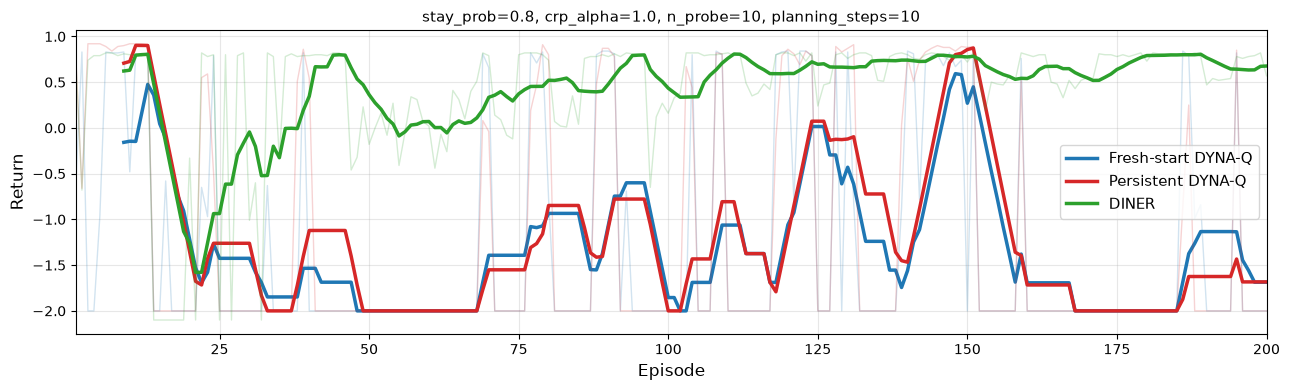

Clusters inferred: 3  (true environments: 3)
Mean return: Fresh=-1.291 | Persistent=-1.192 | DINER=0.429


In [10]:
# === Change any of these and re-run ===
n_episodes_e   = 200
stay_prob_e    = 0.80  # try 0.5 (frequent switches) or 0.95 (rare switches)
crp_alpha_e    = 1.0   # try 0.1, 1.0, 5.0, 50.0
n_probe_e      = 10    # try 2, 4, 8: how small can you go?
planning_e     = 10
eta_e          = 0.1
epsilon_e      = 0.15
# =======================================

set_seed(1)
seq_e = generate_sticky_env_sequence(env_names, n_episodes_e, stay_prob=stay_prob_e, seed=1)

fresh_e = run_baseline_sequence(seq_e, envs, eta_e, gamma, epsilon_e, planning_e)
pers_e  = run_persistent_dyna_q_sequence(seq_e, envs, eta_e, gamma, epsilon_e, planning_e)
diner_e, asgn_e, cls_e = run_diner_sequence(
    seq_e, envs,
    crp_alpha=crp_alpha_e, eta=eta_e, gamma=gamma,
    epsilon=epsilon_e, planning_steps=planning_e,
    n_probe=n_probe_e, seed=1,
)

fig, ax = plt.subplots(figsize=(13, 4))
eps_e = np.arange(1, n_episodes_e + 1)
w = 9
for returns, color, label in [
    (fresh_e, 'tab:blue',  'Fresh-start DYNA-Q'),
    (pers_e,  'tab:red',   'Persistent DYNA-Q'),
    (diner_e, 'tab:green', 'DINER'),
]:
    ax.plot(eps_e, returns, color=color, alpha=0.2, linewidth=1)
    ax.plot(eps_e[w - 1:], smooth(returns, w), color=color, linewidth=2.5, label=label)

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Return', fontsize=12)
ax.set_title(
    f'stay_prob={stay_prob_e}, crp_alpha={crp_alpha_e}, n_probe={n_probe_e}, planning_steps={planning_e}',
    fontsize=11,
)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim(1, n_episodes_e)
plt.tight_layout()
plt.show()

print(f'Clusters inferred: {len(cls_e)}  (true environments: {len(env_names)})')
print(f'Mean return: Fresh={np.mean(fresh_e):.3f} | Persistent={np.mean(pers_e):.3f} | DINER={np.mean(diner_e):.3f}')

---
## Summary

You've now implemented and explored **DINER** (Dyna with Inferred Nonparametric Environment Recurrence), an algorithm that shows how nonparametric Bayesian reasoning and model-based RL can be combined to tackle non-stationary environments with unknown structure.

| Concept | Key takeaway |
|---|---|
| **CRP prior** | Rich-get-richer seating rule; $\alpha$ controls how readily new clusters are created; expected cluster count grows with $\alpha \ln(n)$ |
| **Probe** | Deliberate context identification: a single contradiction is conclusive in deterministic settings, but can be expanded to stochastic settings; our simple environments are identifiabile by trying all actions from the start state, but others may require more sophistication |
| **Fresh-start DYNA-Q** | Starts from scratch on every episode with no cross-episode transfer; fails to learn much, especially for long paths like the `s_maze` |
| **Persistent DYNA-Q** | Transfers everything, but mixes everything together; i.e., `top_right` (UP/RIGHT) and `bottom_left` (DOWN/LEFT) point in exactly opposite directions |
| **DINER** | Selective transfer by reusing familiar environment models and creating new clusters only inconsistent with past models |

When environments have **diametrically opposite optimal policies** combined with a **complex long-path environment** (`s_maze`), Fresh-start DYNA-Q isn't able to leverage enough experience to learn effectively, while Persistent DYNA-Q bounces back and forth from different, inconsistent policies. DINER, by contrast, solves each environment from its first re-encounter onward using the correctly retrieved Q-values.

**Further extensions**

1. **Stochastic environments.** Here we used deterministic environments, where a single contradictory transition is conclusive. In stochastic settings, the same (s,a) can lead to different next states, so contradictions must be treated as soft evidence. A likelihood ratio can replace the binary consistency check, and the posterior becomes a proper Bayesian update (Gershman, Blei, & Niv, 2010).

2. **Adaptive probing.** The probe currently uses a fixed number of random steps. A more efficient approach would be to stop as soon as a definitive contradiction is found, or to keep going when more evidence is needed. More ambitiously, the probe design could more actively select an action sequence that maximally discriminates between candidate clusters.

3. **Mid-episode context detection.** We assumed the environment never changes *within* an episode. Extending DINER to detect mid-episode switches would require monitoring probe consistency against incoming transitions throughout the episode, not just at the start.

4. **Warm-starting new clusters from prior knowledge.** When DINER opens a new cluster, its Q-values are currently initialised to all zeros, meaning the agent must learn the new environment from scratch. A natural extension is to **initialise from the most similar existing cluster**. For instance, by computing a weighted average of all stored Q-tables, with weights proportional to probe similarity. An environment that shares start-state structure with a known environment but differs in its interior would inherit partially correct Q-values, potentially reducing the number of episodes needed to reach the goal. This aligns with recent work on hippocampal remapping (Sanders, Wilson & Gershman, 2020; Tessereau et al., 2025).


### What's next? → Day 2 Track 1

Watching DINER outperform the baselines is encouraging, but performance curves alone do not establish that DINER is the right model for human behaviour. A simpler agent with different parameters might produce qualitatively similar curves. *How might we design an experiment that will allow us to test DINER against alternative models?*

**Day 2 Track 1** addresses this question using robustness checks from [Wilson & Collins (eLife 2019)](https://doi.org/10.7554/eLife.49547):

| Check | Question |
|---|---|
| **Parameter recovery** | If we simulate DINER with true $(\eta^*, \alpha^*, \gamma^*, \tau^*)$ and then fit DINER back, do we recover similar estimates of $(\hat{\eta}, \hat{\alpha}, \hat{\gamma}, \hat{\tau})$? |
| **Model recovery** | If data were generated by model A (DINER, Fresh-start, or Persistent), does comparing BIC across all three correctly identify A? |

Both checks depend not only on the nature of the models in the hypothesis set, but also on the **experimental design**: maze layouts and the environment sequence dynamics must force the three models to produce genuinely different behavioural signatures. Your task tomorrow is to iterate over designs to see if you can pass both of these robustness checks.

**Further reading**

Collins, A. G. E., & Frank, M. J. (2013). Cognitive control over learning: creating, clustering, and generalizing task-set structure. *Psychological Review*, 120(1), 190–229. https://doi.org/10.1037/a0030852

Gershman, S. J., Blei, D. M., & Niv, Y. (2010). Context, learning, and extinction. *Psychological Review*, 117(1), 197–209. https://doi.org/10.1037/a0017808

Gershman, S. J., & Niv, Y. (2010). Learning latent structure: carving nature at its joints. *Current Opinion in Neurobiology*, 20(2), 251–256. https://doi.org/10.1016/j.conb.2010.02.008

Sanders, H., Wilson, M. A., & Gershman, S. J. (2020). Hippocampal remapping as hidden state inference. *Elife*, 9, e51140. https://doi.org/10.7554/eLife.51140 

Sutton, R. S. (1991). Dyna, an integrated architecture for learning, planning, and reacting. *ACM SIGART Bulletin*, 2(4), 160–163. https://doi.org/10.1145/122344.122377

Taylor, M. E., & Stone, P. (2009). Transfer learning for reinforcement learning domains: a survey. *Journal of Machine Learning Research*, 10, 1633–1685. https://jmlr.org/papers/v10/taylor09a.html

Tessereau, C., Xuan, F., Jack, R. M., Dayan, P., & Dombeck, D. (2025). Navigating uncertainty: reward location variability induces reorganization of hippocampal spatial representations. *bioRxiv*. https://doi.org/10.1101/2025.01.06.631465

Wang, Z., Chen, C., & Dong, D. (2022). A Dirichlet process mixture of robust task models for scalable lifelong reinforcement learning. *IEEE Transactions on Cybernetics*, 53(12), 7509–7520. https://ieeexplore.ieee.org/document/9777250

Wilson, A., Fern, A., Ray, S., & Tadepalli, P. (2007). Multi-task reinforcement learning: a hierarchical Bayesian approach. *ICML*, 1015–1022. https://doi.org/10.1145/1273496.1273624

Wilson, R. C., & Collins, A. G. (2019). Ten simple rules for the computational modeling of behavioral data. *elife*, 8, e49547. https://doi.org/10.7554/eLife.49547